In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import enum

In [4]:
task_types = [
    # [Lab 4] Фільтр Калмана: Матричні операції
    {"name": "Kalman (Lab4)", "mean_time": 0.34, "color": "cyan"},
    # [Lab 3] ШПФ (FFT): Оптимізований алгоритм O(N log N)
    {"name": "FFT (Lab3)", "mean_time": 1.77, "color": "blue"},
    # [Lab 6] Розширення спектру (DSSS): Лінійні операції
    {"name": "DSSS (Lab6)", "mean_time": 4.0, "color": "magenta"},
    # [Lab 2] Автокореляція (ACF): O(N^2)
    {"name": "ACF (Lab2)", "mean_time": 7.0, "color": "purple"},
    # [Lab 1] Генерація ВВ: Створення великих масивів
    {"name": "Rand Gen (Lab1)", "mean_time": 8.0, "color": "orange"},
    # [Lab 5] MCTS: Пошук по дереву, ітеративний процес
    {"name": "MCTS (Lab5)", "mean_time": 20.0, "color": "green"},
    # [Lab 3] ДПФ (DFT): O(N^2)
    {"name": "DFT (Lab3)", "mean_time": 66.6, "color": "red"}
]

# Розрахунок середнього навантаження
avg_exec_time = np.mean([t["mean_time"] for t in task_types])
critical_intensity = 1.0 / avg_exec_time

print(f"Середній час задачі: {avg_exec_time:.2f} мс")
print(f"Теоретична межа насичення: {critical_intensity:.4f} заявок/мс")

Середній час задачі: 15.39 мс
Теоретична межа насичення: 0.0650 заявок/мс


In [5]:
class Task:
    def __init__(self, id, arrival_time, type_idx):
        self.id = id
        self.arrival_time = arrival_time
        self.type_info = task_types[type_idx]

        # Час виконання: середнє + std 20%
        mean = self.type_info["mean_time"]
        self.execution_time = max(0.1, np.random.normal(mean, mean * 0.2))
        self.remaining_time = self.execution_time

        # Дедлайн
        slack_factor = random.uniform(1.5, 5.0)
        self.deadline = arrival_time + self.execution_time * slack_factor

        self.start_time = -1
        self.finish_time = -1
        self.wait_time = 0

class SchedulerType(enum.Enum):
    RR = "Round Robin"
    EDF = "Earliest Deadline First"

class SystemSimulator:
    def __init__(self, scheduler_type, intensity, quantum=5.0):
        self.scheduler_type = scheduler_type
        self.intensity = intensity
        self.quantum = quantum

        self.current_time = 0.0
        self.queue = deque()
        self.completed_tasks = []
        self.missed_deadlines = 0
        self.processor_busy_time = 0.0
        self.queue_sizes = []

    def generate_tasks(self, duration):
        tasks = []
        t = 0
        task_id = 0
        while t < duration:
            inter_arrival = np.random.exponential(1.0 / self.intensity)
            t += inter_arrival
            if t >= duration: break

            type_idx = random.randint(0, len(task_types) - 1)
            tasks.append(Task(task_id, t, type_idx))
            task_id += 1

        return tasks

    def run(self, simulation_duration):
        incoming_tasks = deque(self.generate_tasks(simulation_duration))
        current_task = None
        dt = 0.1
        time_slice = 0

        while self.current_time < simulation_duration:
            # 1. Прихід нових задач
            while incoming_tasks and incoming_tasks[0].arrival_time <= self.current_time:
                self.queue.append(incoming_tasks.popleft())

            self.queue_sizes.append(len(self.queue))

            # 2. Планувальник
            if self.scheduler_type == SchedulerType.RR:
                if not current_task and self.queue:
                    current_task = self.queue.popleft()
                    if current_task.start_time == -1: current_task.start_time = self.current_time
                    time_slice = 0

                if current_task:
                    self._process_task(current_task, dt)
                    time_slice += dt

                    if current_task.remaining_time <= 0:
                        self._complete_task(current_task)
                        current_task = None
                        time_slice = 0
                    elif time_slice >= self.quantum:
                        self.queue.append(current_task)
                        current_task = None
                        time_slice = 0

            elif self.scheduler_type == SchedulerType.EDF:
                if self.queue:
                    # Пошук задачі з мінімальним дедлайном
                    best_idx = 0
                    min_d = self.queue[0].deadline
                    for i in range(1, len(self.queue)):
                        if self.queue[i].deadline < min_d:
                            min_d = self.queue[i].deadline
                            best_idx = i

                    best_candidate = self.queue[best_idx]

                    # Логіка витіснення
                    if not current_task:
                        current_task = best_candidate
                        del self.queue[best_idx]
                        if current_task.start_time == -1: current_task.start_time = self.current_time
                    elif best_candidate.deadline < current_task.deadline:
                        self.queue.append(current_task) # Повертаємо поточну в чергу
                        current_task = best_candidate
                        del self.queue[best_idx]
                        if current_task.start_time == -1: current_task.start_time = self.current_time

                if current_task:
                    self._process_task(current_task, dt)
                    if current_task.remaining_time <= 0:
                        self._complete_task(current_task)
                        current_task = None

            self.current_time += dt

        return {
            "avg_wait": np.mean([t.wait_time for t in self.completed_tasks]) if self.completed_tasks else 0,
            "missed_pct": (self.missed_deadlines / len(self.completed_tasks) * 100) if self.completed_tasks else 0,
            "idle_pct": max(0, (1.0 - (self.processor_busy_time / self.current_time)) * 100),
            "queue_avg": np.mean(self.queue_sizes)
        }

    def _process_task(self, task, dt):
        self.processor_busy_time += dt
        task.remaining_time -= dt

    def _complete_task(self, task):
        task.finish_time = self.current_time
        task.wait_time = task.finish_time - task.arrival_time - task.execution_time
        if task.finish_time > task.deadline:
            self.missed_deadlines += 1
        self.completed_tasks.append(task)

In [14]:
intensities = np.linspace(0.01, 0.1, 20)
simulation_time = 5000

res_rr = {"x": [], "wait": [], "missed": [], "idle": []}
res_edf = {"x": [], "wait": [], "missed": [], "idle": []}


for intensity in intensities:
    # Round Robin
    sim_rr = SystemSimulator(SchedulerType.RR, intensity, quantum=5.0)
    data_rr = sim_rr.run(simulation_time)
    res_rr["x"].append(intensity)
    res_rr["wait"].append(data_rr["avg_wait"])
    res_rr["missed"].append(data_rr["missed_pct"])
    res_rr["idle"].append(data_rr["idle_pct"])

    # EDF
    sim_edf = SystemSimulator(SchedulerType.EDF, intensity)
    data_edf = sim_edf.run(simulation_time)
    res_edf["x"].append(intensity)
    res_edf["wait"].append(data_edf["avg_wait"])
    res_edf["missed"].append(data_edf["missed_pct"])
    res_edf["idle"].append(data_edf["idle_pct"])

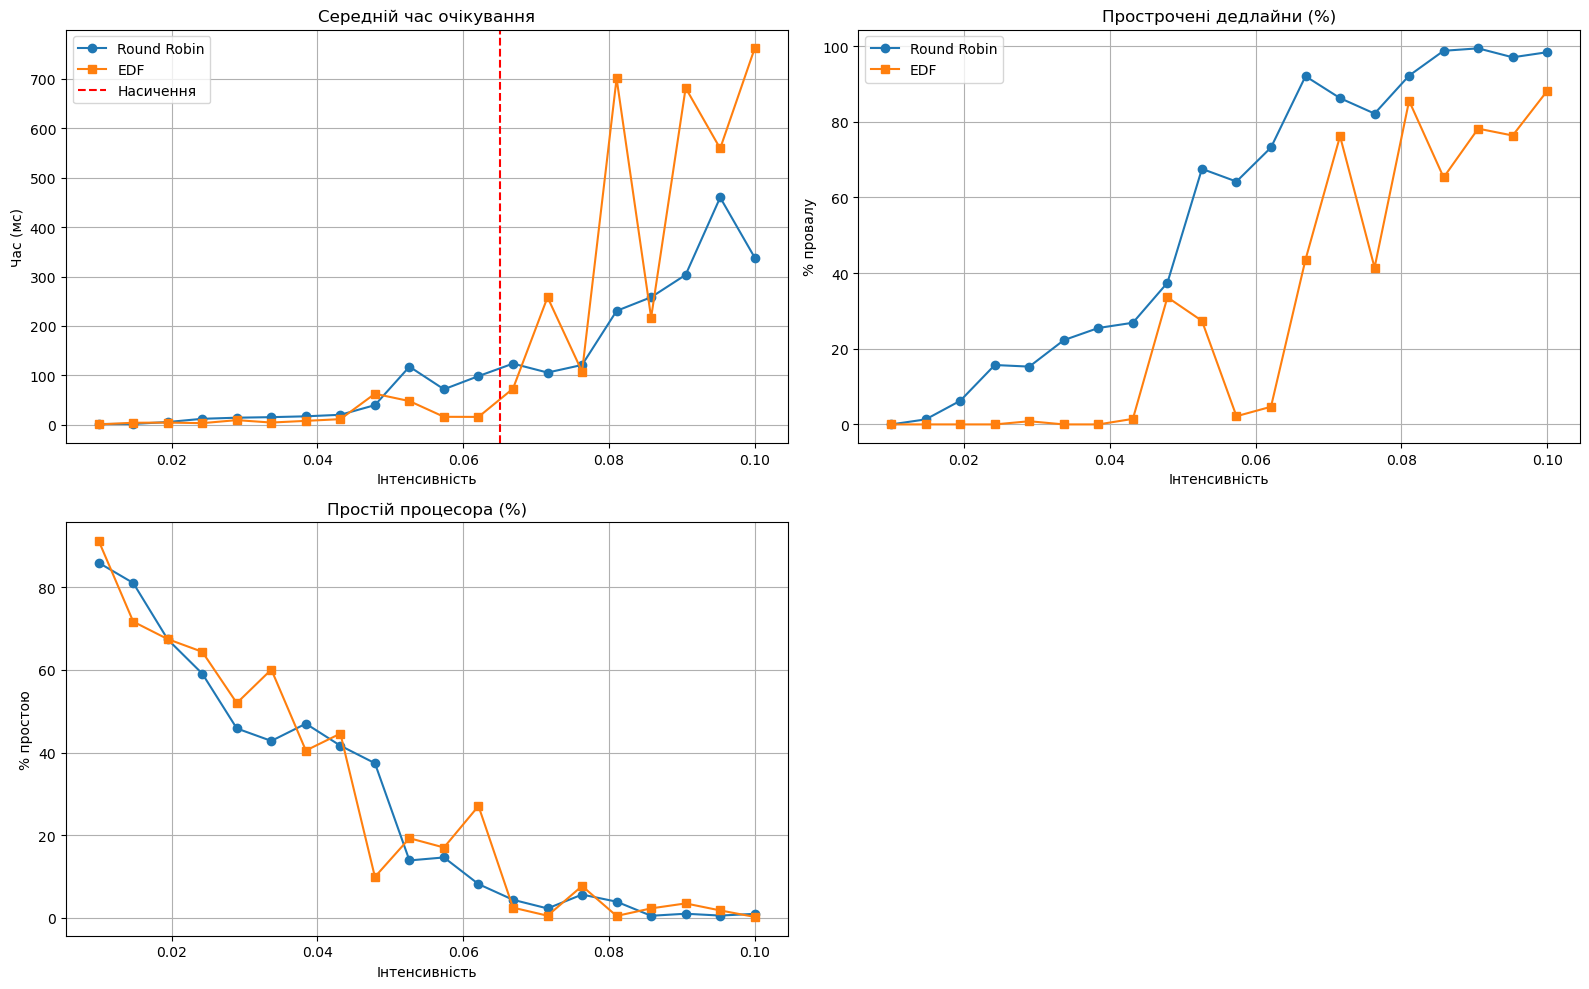

In [15]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(res_rr["x"], res_rr["wait"], 'o-', label='Round Robin')
plt.plot(res_edf["x"], res_edf["wait"], 's-', label='EDF')
plt.axvline(x=critical_intensity, color='red', linestyle='--', label='Насичення')
plt.title("Середній час очікування")
plt.xlabel("Інтенсивність")
plt.ylabel("Час (мс)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(res_rr["x"], res_rr["missed"], 'o-', label='Round Robin')
plt.plot(res_edf["x"], res_edf["missed"], 's-', label='EDF')
plt.title("Прострочені дедлайни (%)")
plt.xlabel("Інтенсивність")
plt.ylabel("% провалу")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(res_rr["x"], res_rr["idle"], 'o-', label='Round Robin')
plt.plot(res_edf["x"], res_edf["idle"], 's-', label='EDF')
plt.title("Простій процесора (%)")
plt.xlabel("Інтенсивність")
plt.ylabel("% простою")
plt.grid(True)

plt.tight_layout()
plt.show()